## Hospital Operations and Patient Data Analysis

## Project Objective
Analyze hospital and patient data to identify trends, improve efficiency, and support better decision-making.

## Dataset Overview

The dataset contains hospital and patient-related information including demographics, medical conditions, billing amounts, admission types, discharge details, room allocation, insurance providers, and medical test results.

The dataset consists of 55,500 patient records and multiple operational variables useful for healthcare analysis.

#  Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  Load Dataset

In [3]:
df = pd.read_csv("../data/healthcare_dataset.csv")

## Data Understanding

This section explores the dataset structure, identifies data types, checks missing values, and helps understand available variables before cleaning and analysis.

In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


## Data Cleaning and Preprocessing

Data preprocessing ensures that the dataset is clean, consistent, and ready for analysis. This includes handling dates, validating data formats, and preparing variables for analysis.

In [6]:
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [7]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'],
    dayfirst=True
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'],
    dayfirst=True
)

## Feature Engineering

Feature engineering involves creating new variables from existing data to improve analytical value.

A new feature called Length of Stay was created using admission and discharge dates to measure patient stay duration.

In [8]:
df['Length of Stay'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

In [9]:
df[['Date of Admission','Discharge Date','Length of Stay']].head()

,Date of Admission,Discharge Date,Length of Stay
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


## Statistical Summary

In [45]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Length of Stay
count,55500.000000,55500,55500.000000,55500.000000,55500,55500.000000
mean,51.539459,2021-11-01 01:02:22.443243,25539.316097,301.134829,2021-11-16 13:15:20.821621,15.509009
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13241.224655,202.000000,2020-08-12 00:00:00,8.000000
50%,52.000000,2021-11-01 00:00:00,25538.069380,302.000000,2021-11-17 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37820.508432,401.000000,2023-02-18 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276740,500.000000,2024-06-06 00:00:00,30.000000
std,19.602454,NaN,14211.454431,115.243069,NaN,8.659600


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps uncover patterns, distributions, relationships, and operational insights from hospital data.

In [10]:
df['Billing Amount'].mean()

np.float64(25539.316097199626)

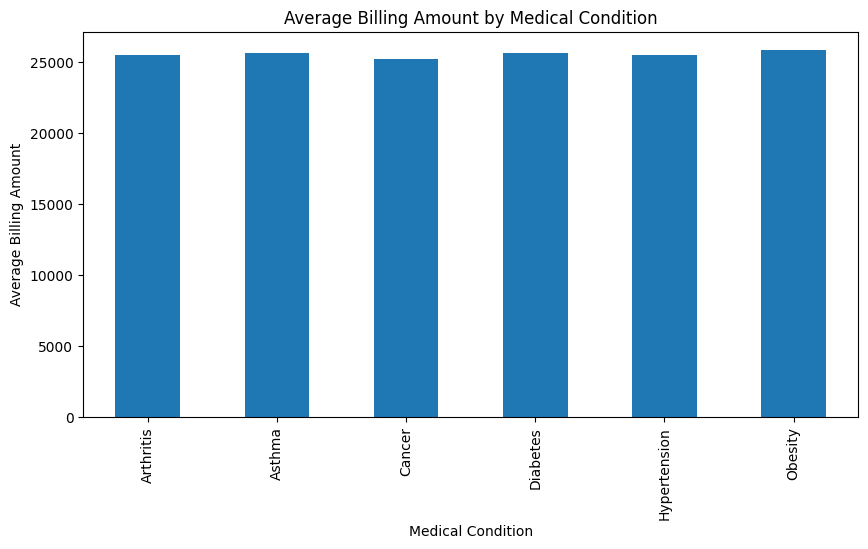

In [44]:
plt.figure(figsize=(10,5))
billing = df.groupby('Medical Condition')['Billing Amount'].mean()

billing.plot(kind='bar')

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')

plt.savefig('../charts/average_billing_by_disease.png')
plt.show()

Insight:

Higher billing amounts may indicate increased treatment complexity and resource utilization.

In [12]:
df['Length of Stay'].mean()

np.float64(15.50900900900901)

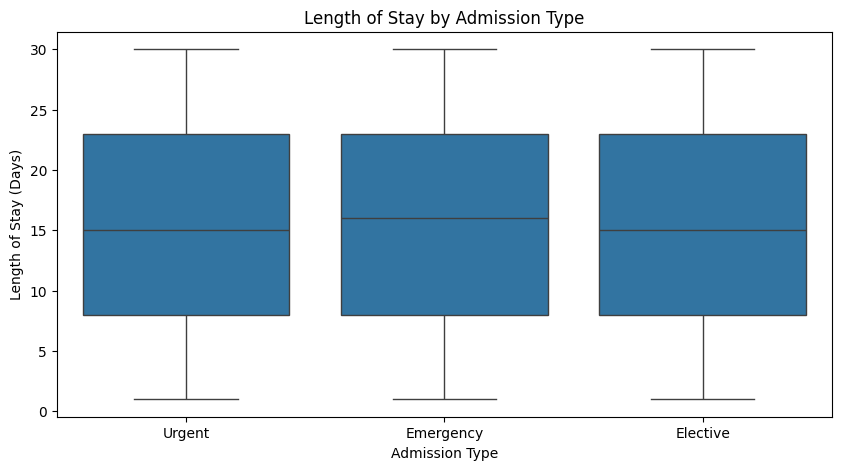

In [50]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='Admission Type',
    y='Length of Stay',
    data=df
)

plt.title('Length of Stay by Admission Type')
plt.xlabel('Admission Type')
plt.ylabel('Length of Stay (Days)')

plt.savefig('../charts/age_distribution.png')

plt.show()

In [15]:
df.to_csv('../data/cleaned_hospital_data.csv', index=False)

## Patient Demographics Analysis

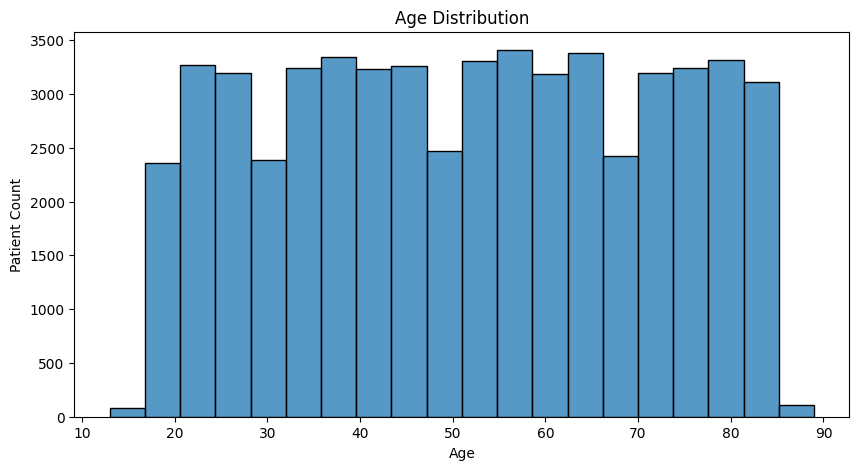

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(df['Age'], bins=20)

plt.xlabel('Age')
plt.ylabel('Patient Count')
plt.title('Age Distribution')

plt.savefig('../charts/age_distribution.png')
plt.show()

Insight:
The age distribution indicates that hospital patients are spread across multiple age groups, suggesting diverse healthcare demands across the population.

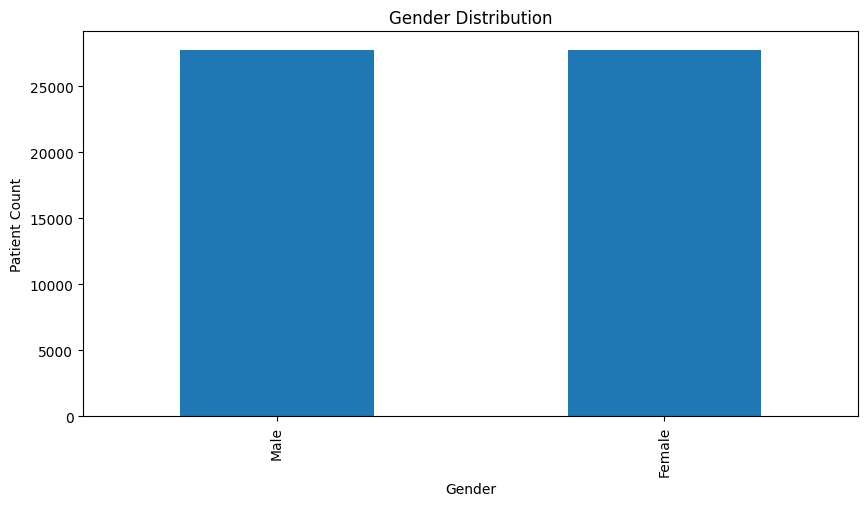

In [42]:
plt.figure(figsize=(10,5))
df['Gender'].value_counts().plot(kind='bar')


plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Patient Count')

plt.savefig('../charts/gender_distribution.png')
plt.show()

Insight:
Male and female patient counts are nearly balanced, indicating equal healthcare utilization across genders in this dataset.

## Medical Condition Analysis

In [18]:
df['Medical Condition'].value_counts()

Medical Condition
Arthritis       9308
Diabetes        9304
Hypertension    9245
Obesity         9231
Cancer          9227
Asthma          9185
Name: count, dtype: int64

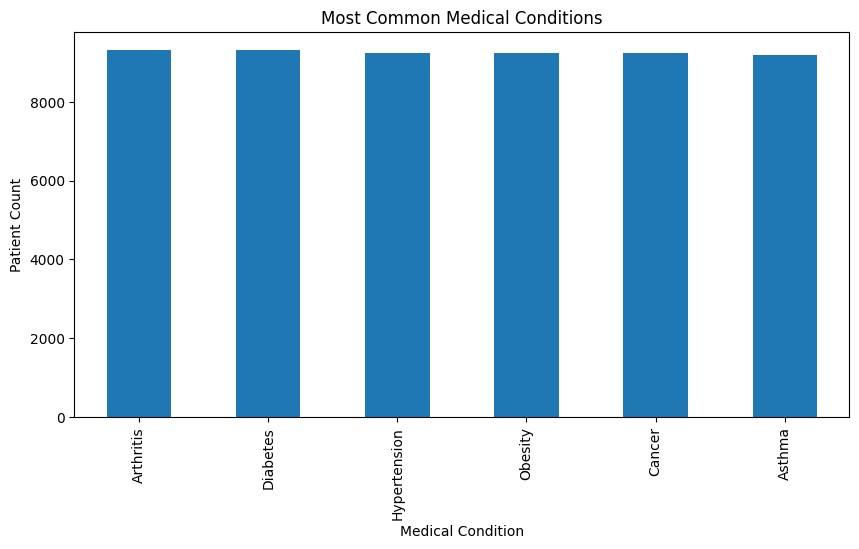

In [46]:
plt.figure(figsize=(10,5))
df['Medical Condition'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)
plt.xlabel('Medical Condition')
plt.ylabel('Patient Count')
plt.title('Most Common Medical Conditions')

plt.savefig('../charts/medical_condition_distribution.png')
plt.show()

Insight:
Arthritis, Diabetes, and Hypertension are among the most common medical conditions observed, indicating high demand for chronic disease management.

## Billing Analysis

In [20]:
df['Billing Amount'].mean()

np.float64(25539.316097199626)

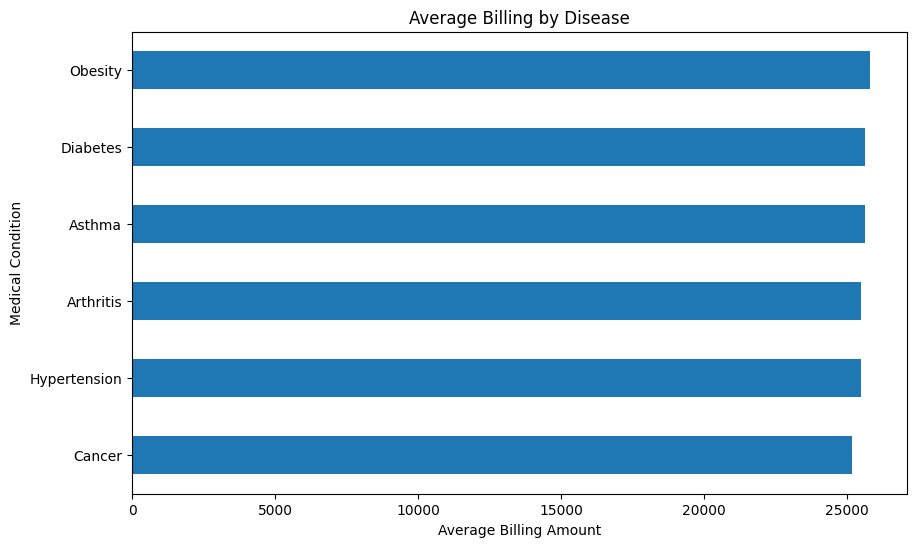

In [40]:
plt.figure(figsize=(10,5))
billing.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Average Billing by Disease')
plt.xlabel('Average Billing Amount')
plt.ylabel('Medical Condition')

plt.savefig('../charts/average_billing_by_disease.png')
plt.show()

Average Billing Amount:
25,539.32

Insight:
Obesity, Diabetes, and Asthma show relatively higher average billing amounts, suggesting increased treatment complexity and resource usage.

## Admission Type Analysis

In [22]:
df['Admission Type'].value_counts()

Admission Type
Elective     18655
Urgent       18576
Emergency    18269
Name: count, dtype: int64

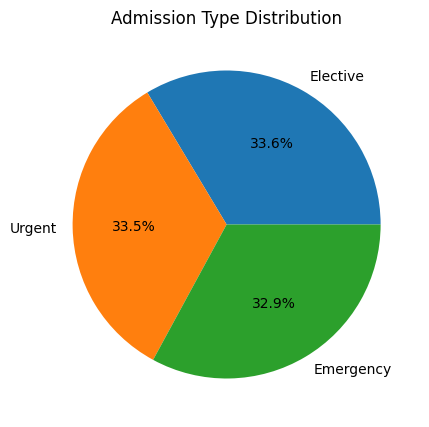

In [23]:
plt.figure(figsize=(10,5))
df['Admission Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Admission Type Distribution')

plt.ylabel('')

plt.show()

Results :
- Elective Admissions: 18,655  
- Urgent Admissions: 18,576  
- Emergency Admissions: 18,269

Insight:

Admission types are relatively balanced, suggesting hospitals must maintain readiness for both planned and emergency care requirements.

## Room Utilisation Analysis

In [24]:
df['Room Number'].value_counts().head(10)

Room Number
393    181
491    177
104    175
420    175
392    171
209    171
208    169
147    168
214    168
279    168
Name: count, dtype: int64

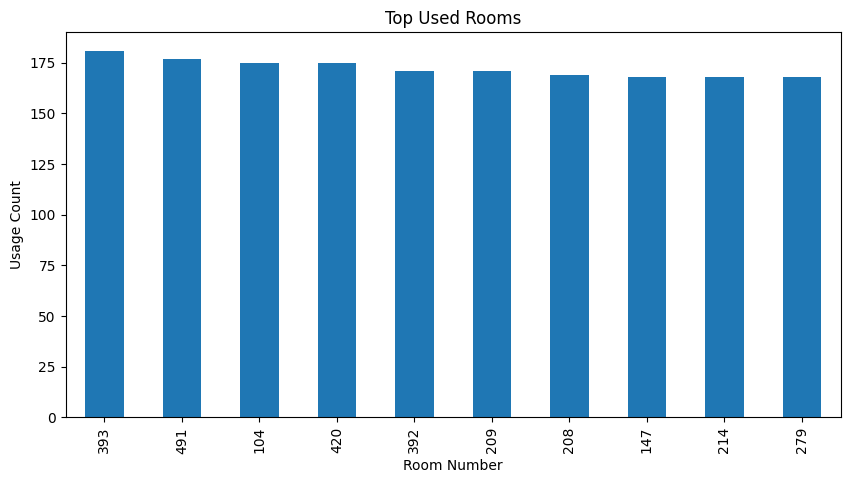

In [39]:
plt.figure(figsize=(10,5))
df['Room Number'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top Used Rooms')
plt.xlabel('Room Number')
plt.ylabel('Usage Count')

plt.savefig('../charts/room_usage.png')
plt.show()

Insight:
Some rooms experience higher occupancy than others, suggesting potential opportunities for improved room allocation and scheduling efficiency.

## Correlation and Statistical Analysis

## Outlier Detection

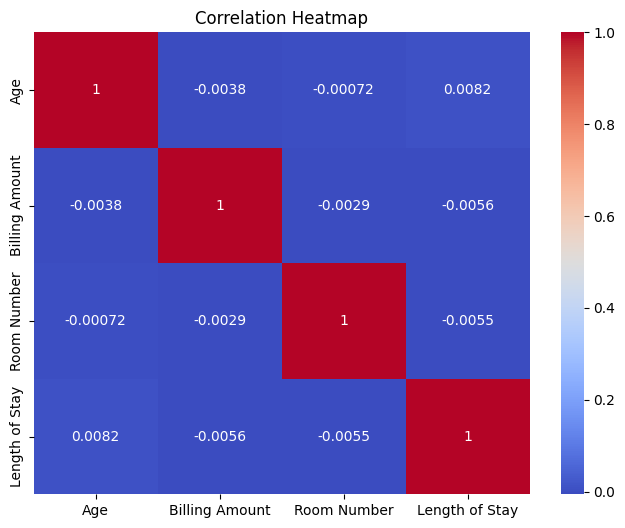

In [48]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

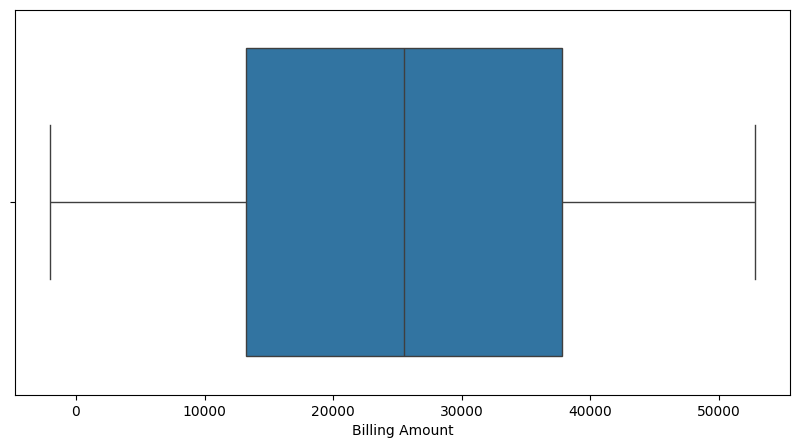

In [47]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Billing Amount'])

plt.show()

Insight:
Billing data contains high-value outliers, indicating certain treatments or cases may involve significantly higher healthcare costs.

# Insurance Provider Analysis

In [29]:
df['Insurance Provider'].value_counts()

Insurance Provider
Cigna               11249
Medicare            11154
UnitedHealthcare    11125
Blue Cross          11059
Aetna               10913
Name: count, dtype: int64

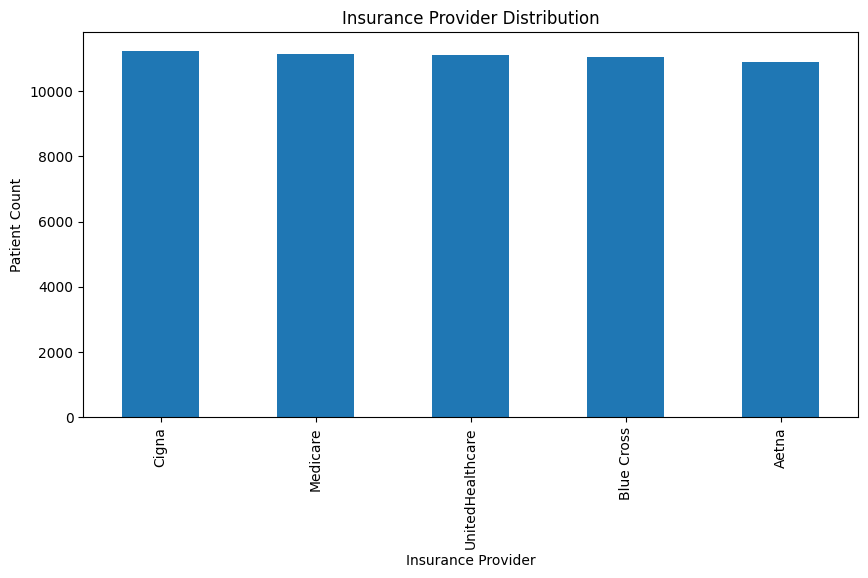

In [53]:
plt.figure(figsize=(10,5))
df['Insurance Provider'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Insurance Provider Distribution')
plt.xlabel('Insurance Provider')
plt.ylabel('Patient Count')

plt.savefig('../charts/insurance_provider_distribution.png')
plt.show()

Insight:
Insurance coverage is distributed across multiple providers, with Cigna, Medicare, and UnitedHealthcare serving a large portion of patients.

# Test Result Analysis

In [31]:
df['Test Results'].value_counts()

Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64

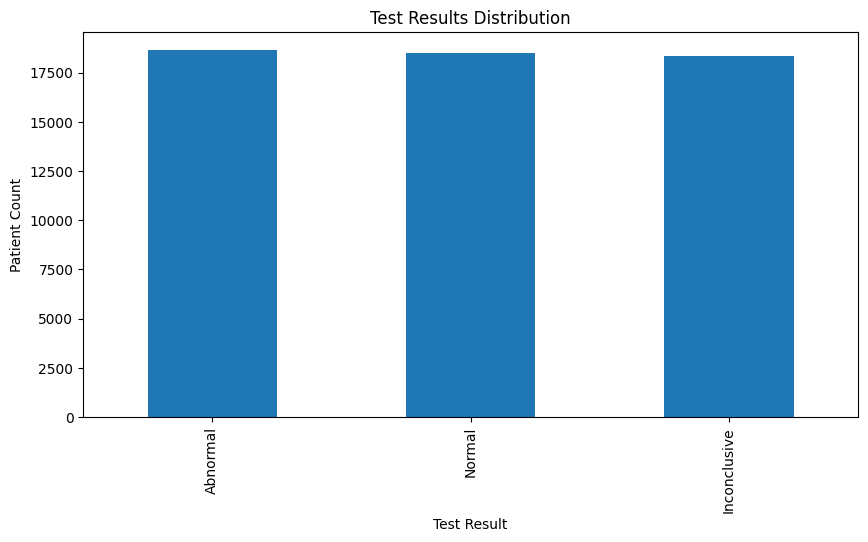

In [52]:
plt.figure(figsize=(10,5))
df['Test Results'].value_counts().plot(
    kind='bar'
)

plt.title('Test Results Distribution')
plt.xlabel('Test Result')
plt.ylabel('Patient Count')

plt.savefig('../charts/test_results_distribution.png')

plt.show()

Results:
- Abnormal: 18,627
- Normal: 18,517
- Inconclusive: 18,356

## Key Findings

- Average billing amount is approximately 25,539.
- Average patient stay is 15.5 days.
- Chronic conditions such as Arthritis and Diabetes are highly common.
- Admission categories are relatively balanced.
- Billing outliers indicate expensive treatment cases.
- Room utilization patterns suggest operational optimization opportunities.

## Recommendations

1. Improve Room Allocation
Hospitals should optimize room assignment and scheduling to improve occupancy efficiency.

2. Reduce Prolonged Stays
Improving discharge planning may help reduce unnecessary hospital stays and lower operational costs.

3. Strengthen Preventive Care
High-frequency chronic diseases suggest opportunities for preventive healthcare programs.

4. Monitor High-Cost Treatments
Billing outliers should be analysed to identify cost-saving opportunities and improve financial efficiency.

5. Improve Resource Planning
Balanced admission categories require hospitals to maintain flexible staffing and operational readiness.

## Business Impact

This analysis provides valuable operational insights that can support hospital management in improving resource utilization, optimizing patient flow, reducing operational costs, and enhancing patient care quality.

The findings may support better strategic decision-making, healthcare planning, and service efficiency improvements.

## Conclusion

This project analysed hospital and patient data to identify operational patterns, billing behaviour, and patient care trends.

The analysis demonstrated how healthcare analytics can support informed decision-making and operational improvements. Through data cleaning, feature engineering, visualization, and statistical analysis, meaningful insights and practical recommendations were generated to support hospital efficiency and patient outcomes.